<a href="https://colab.research.google.com/github/Statisticsage/autovaluate/blob/main/Dehko_dataste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
dehko = pd.read_csv("/cardekho_dataset.csv")
dehko.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
dehko.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [ ]:
dehko.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [ ]:
dehko.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage(km/ltr/kg),221
engine,221


In [ ]:
dehko['fuel'].value_counts()

,count
fuel,
Diesel,4402
Petrol,3631
CNG,57
LPG,38


In [ ]:
dehko['transmission'].value_counts()


,count
transmission,
Manual,7078
Automatic,1050


In [ ]:
dehko['seller_type'].value_counts()

,count
seller_type,
Individual,6766
Dealer,1126
Trustmark Dealer,236


In [ ]:
dehko['max_power'].head(10)

,max_power
0,74
1,103.52
2,78
3,90
4,88.2
5,81.86
6,57.5
7,37
8,67.1
9,68.1


In [ ]:
dehko['max_power'].unique()[:20]

array(['74', '103.52', '78', '90', '88.2', '81.86', '57.5', '37', '67.1',
       '68.1', '108.45', '60', '73.9', nan, '67', '82', '88.5', '46.3',
       '88.73', '64.1'], dtype=object)

In [ ]:

##Data Cleaning

In [ ]:
dehko['max_power'] = pd.to_numeric(dehko['max_power'], errors='coerce')

In [ ]:
dehko_clean = dehko.dropna()
print(dehko_clean.shape)

(7906, 12)


In [ ]:
dehko_clean['brand'] = dehko_clean['name'].str.split().str[0]
dehko_clean['brand'].value_counts()

/tmp/ipykernel_27945/3524380404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dehko_clean['brand'] = dehko_clean['name'].str.split().str[0]


,count
brand,
Maruti,2367
Hyundai,1360
Mahindra,758
Tata,719
Honda,466
Toyota,452
Ford,388
Chevrolet,230
Renault,228


In [ ]:
dehko_clean['car_age'] = 2024 - dehko_clean['year']

/tmp/ipykernel_27945/1462429731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dehko_clean['car_age'] = 2024 - dehko_clean['year']


In [ ]:
dehko_clean = dehko.dropna().copy()

In [ ]:
# Re-initialize dehko_clean to ensure it's a fresh copy after dropping NaNs
dehko_clean = dehko.dropna().copy()

In [ ]:
# Now the 'brand' column
dehko_clean['brand'] = dehko_clean['name'].str.split().str[0]
print("Brand column created. First 5 brands:")
display(dehko_clean['brand'].head(10))

Brand column created. First 5 brands:


,brand
0,Maruti
1,Skoda
2,Honda
3,Hyundai
4,Maruti
5,Hyundai
6,Maruti
7,Maruti
8,Toyota
9,Ford


In [ ]:
# Apply the brand name replacements
dehko_clean['brand'] = dehko_clean['brand'].replace({
    'Land': 'Land Rover',
    'Force': 'Force Motors',
    'Ashok': 'Ashok Leyland'
})
print("Brand names replaced. Value counts after replacement:")
display(dehko_clean['brand'].value_counts().head())

Brand names replaced. Value counts after replacement:


,count
brand,
Maruti,2367
Hyundai,1360
Mahindra,758
Tata,719
Honda,466


In [ ]:
# Finally, re-create the 'car_age' column
dehko_clean['car_age'] = 2024 - dehko_clean['year']
print("Car age column created. First 5 car ages:")
display(dehko_clean['car_age'].head())

Car age column created. First 5 car ages:


,car_age
0,10
1,10
2,18
3,14
4,17


All the necessary columns should now be correctly processed in `dehko_clean` without errors. You can now re-run the `describe()` method if you wish.

In [ ]:
print(dehko_clean['brand'].unique())

['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi' 'Audi'
 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land Rover' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Fiat' 'Force Motors' 'Ambassador' 'Ashok Leyland' 'Isuzu'
 'Opel']


In [ ]:
dehko_clean[['selling_price', 'km_driven', 'year']].describe()

,selling_price,km_driven,year
count,7.906000e+03,7.906000e+03,7906.000000
mean,6.498137e+05,6.918866e+04,2013.983936
std,8.135827e+05,5.679230e+04,3.863695
min,2.999900e+04,1.000000e+00,1994.000000
25%,2.700000e+05,3.500000e+04,2012.000000
50%,4.500000e+05,6.000000e+04,2015.000000
75%,6.900000e+05,9.542500e+04,2017.000000
max,1.000000e+07,2.360457e+06,2020.000000


In [ ]:
price_cap = dehko_clean['selling_price'].quantile(0.99)
km_cap = dehko_clean['km_driven'].quantile(0.99)

dehko_clean = dehko_clean[
    (dehko_clean['selling_price'] <= price_cap) &
    (dehko_clean['km_driven'] <= km_cap)
]
print(dehko_clean.shape)

(7749, 14)


DATA Exploratory

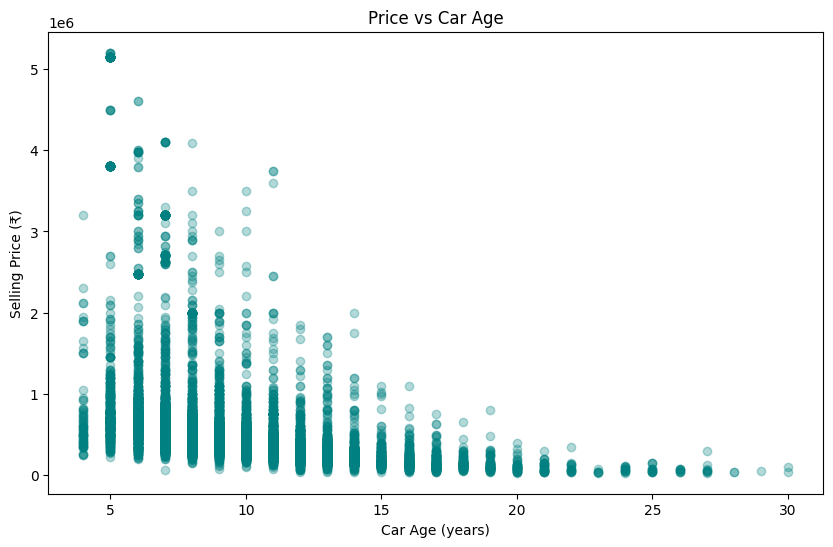

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(dehko_clean['car_age'], dehko_clean['selling_price'], alpha=0.3, color='teal')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price (₹)')
plt.title('Price vs Car Age')
plt.show()

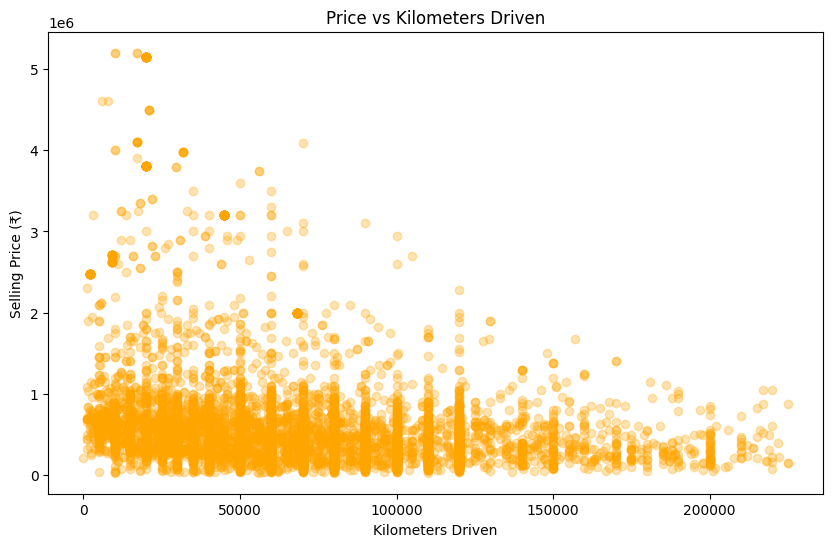

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(dehko_clean['km_driven'], dehko_clean['selling_price'], alpha=0.3, color='orange')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (₹)')
plt.title('Price vs Kilometers Driven')
plt.show()

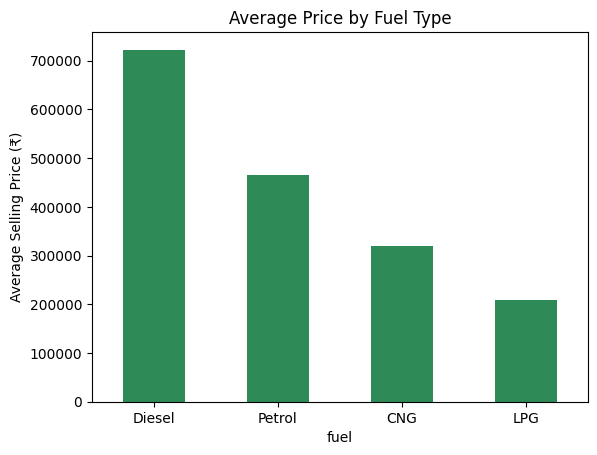

In [ ]:
dehko_clean.groupby('fuel')['selling_price'].mean().sort_values(ascending=False).plot(kind='bar', color='seagreen')
plt.ylabel('Average Selling Price (₹)')
plt.title('Average Price by Fuel Type')
plt.xticks(rotation=0)
plt.show()

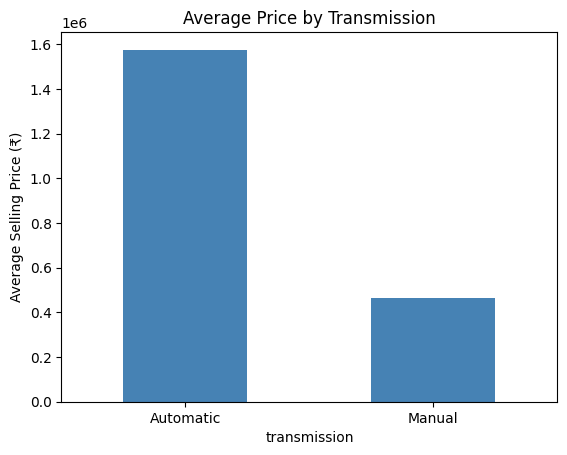

In [ ]:
dehko_clean.groupby('transmission')['selling_price'].mean().plot(kind='bar', color='steelblue')
plt.ylabel('Average Selling Price (₹)')
plt.title('Average Price by Transmission')
plt.xticks(rotation=0)
plt.show()

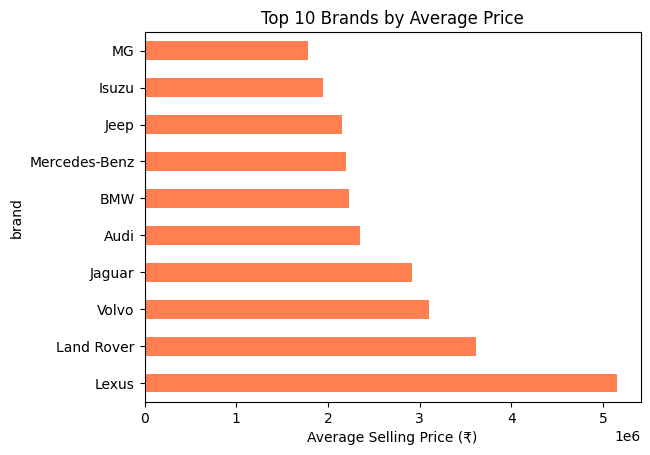

In [ ]:
dehko_clean.groupby('brand')['selling_price'].mean().sort_values(ascending=False).head(10).plot(kind='barh', color='coral')
plt.xlabel('Average Selling Price (₹)')
plt.title('Top 10 Brands by Average Price')
plt.show()

In [ ]:
dehko_clean.columns.tolist()

['name',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage(km/ltr/kg)',
 'engine',
 'max_power',
 'seats',
 'brand',
 'car_age']

In [ ]:
dehko_clean['owner'].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [ ]:
owner_map = {
    'Test Drive Car': 0,
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4
}
dehko_clean['owner_encoded'] = dehko_clean['owner'].map(owner_map)
dehko_clean['owner_encoded'].value_counts()

/tmp/ipykernel_27945/1550799693.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dehko_clean['owner_encoded'] = dehko_clean['owner'].map(owner_map)


,count
owner_encoded,
1,5107
2,1987
3,498
4,155
0,2


In [ ]:
dehko_encoded = pd.get_dummies(dehko_clean, columns=['fuel', 'seller_type', 'transmission', 'brand'], drop_first=True)
print(dehko_encoded.shape)
dehko_encoded.columns.tolist()

(7749, 47)


['name',
 'year',
 'selling_price',
 'km_driven',
 'owner',
 'mileage(km/ltr/kg)',
 'engine',
 'max_power',
 'seats',
 'car_age',
 'owner_encoded',
 'fuel_Diesel',
 'fuel_LPG',
 'fuel_Petrol',
 'seller_type_Individual',
 'seller_type_Trustmark Dealer',
 'transmission_Manual',
 'brand_Ashok Leyland',
 'brand_Audi',
 'brand_BMW',
 'brand_Chevrolet',
 'brand_Daewoo',
 'brand_Datsun',
 'brand_Fiat',
 'brand_Force Motors',
 'brand_Ford',
 'brand_Honda',
 'brand_Hyundai',
 'brand_Isuzu',
 'brand_Jaguar',
 'brand_Jeep',
 'brand_Kia',
 'brand_Land Rover',
 'brand_Lexus',
 'brand_MG',
 'brand_Mahindra',
 'brand_Maruti',
 'brand_Mercedes-Benz',
 'brand_Mitsubishi',
 'brand_Nissan',
 'brand_Opel',
 'brand_Renault',
 'brand_Skoda',
 'brand_Tata',
 'brand_Toyota',
 'brand_Volkswagen',
 'brand_Volvo']

In [ ]:
y = dehko_encoded['selling_price']
X = dehko_encoded.drop(columns=['name', 'year', 'selling_price', 'owner'])

print(X.shape, y.shape)
print(X.columns.tolist())

(7749, 43) (7749,)
['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age', 'owner_encoded', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Manual', 'brand_Ashok Leyland', 'brand_Audi', 'brand_BMW', 'brand_Chevrolet', 'brand_Daewoo', 'brand_Datsun', 'brand_Fiat', 'brand_Force Motors', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land Rover', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Mitsubishi', 'brand_Nissan', 'brand_Opel', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (6199, 43)
Test size: (1550, 43)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE (Mean Absolute Error): ₹{mae:,.0f}")
print(f"RMSE (Root Mean Squared Error): ₹{rmse:,.0f}")
print(f"R² Score: {r2:.4f}")

MAE (Mean Absolute Error): ₹64,210
RMSE (Root Mean Squared Error): ₹118,415
R² Score: 0.9592


In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(15))

max_power                 0.679398
car_age                   0.132150
km_driven                 0.091725
mileage(km/ltr/kg)        0.022845
brand_Lexus               0.018451
engine                    0.016625
brand_Toyota              0.004887
transmission_Manual       0.003765
fuel_Petrol               0.003575
brand_Mercedes-Benz       0.003466
fuel_Diesel               0.003458
seats                     0.002587
brand_Land Rover          0.002324
seller_type_Individual    0.002310
brand_Tata                0.002161
dtype: float64


In [ ]:
import joblib
joblib.dump(model, 'car_price_model.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

from google.colab import files
files.download('car_price_model.pkl')
files.download('model_columns.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dehko_clean.to_csv('cardekho_cleaned.csv', index=False)
from google.colab import files
files.download('cardekho_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn, numpy
print(sklearn.__version__, numpy.__version__)

1.6.1 2.0.2
